In [4]:
from transformers import BigBirdTokenizer
import pandas as pd

/home/mario/miniforge3/envs/xtemp-nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model_id = 'google/bigbird-roberta-base'
tokenizer = BigBirdTokenizer.from_pretrained(model_id, trust_remote_code=True)

## Contexts Token Distribution

Tokenizing entries: 100%|██████████| 142203/142203 [00:50<00:00, 2799.93it/s]


Average token length: 129.45
Median token length: 99.0
Percentiles (25th, 50th, 75th, 90th, 95th, 99th): [ 55.  99. 170. 268. 346. 520.]


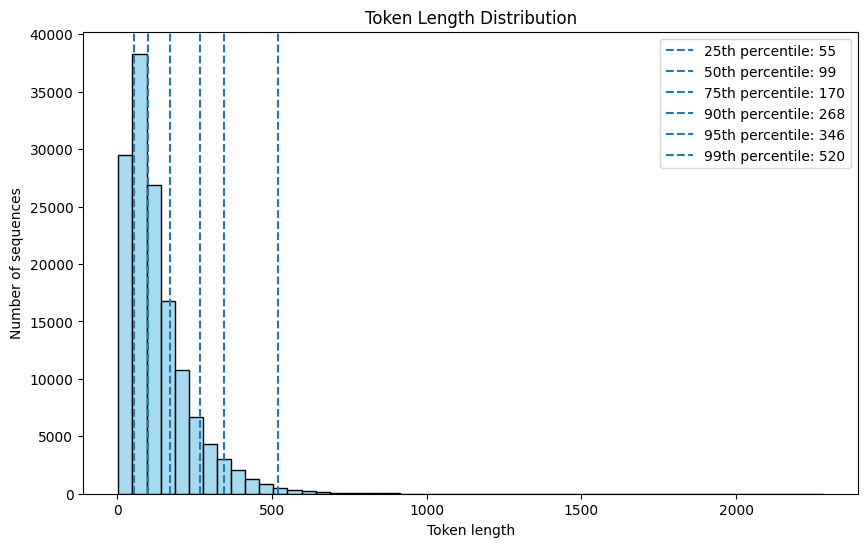

In [23]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('baseline_data/train.csv', sep=',')

token_lengths = []
for entry in tqdm(df['entries'], desc="Tokenizing entries"):
    if not isinstance(entry, str):
        entry = str(entry)
    token_lengths.append(len(tokenizer(entry).input_ids))

token_lengths = np.array(token_lengths)

avg_length = np.mean(token_lengths)
median_length = np.median(token_lengths)
percentiles = np.percentile(token_lengths, [25, 50, 75, 90, 95, 99])

print(f"Average token length: {avg_length:.2f}")
print(f"Median token length: {median_length}")
print("Percentiles (25th, 50th, 75th, 90th, 95th, 99th):", percentiles)

plt.figure(figsize=(10, 6))
sns.histplot(token_lengths, bins=50, kde=False, color="skyblue")
plt.title("Token Length Distribution")
plt.xlabel("Token length")
plt.ylabel("Number of sequences")

for p, val in zip([25, 50, 75, 90, 95, 99], percentiles):
    plt.axvline(val, linestyle='--', label=f'{p}th percentile: {int(val)}')

plt.legend()
plt.show()

Tokenizing entries: 100%|██████████| 2206/2206 [00:00<00:00, 3959.36it/s]


Average token length: 118.83
Median token length: 101.0
Percentiles (25th, 50th, 75th, 90th, 95th, 99th): [ 64.  101.  154.  217.  268.  398.9]


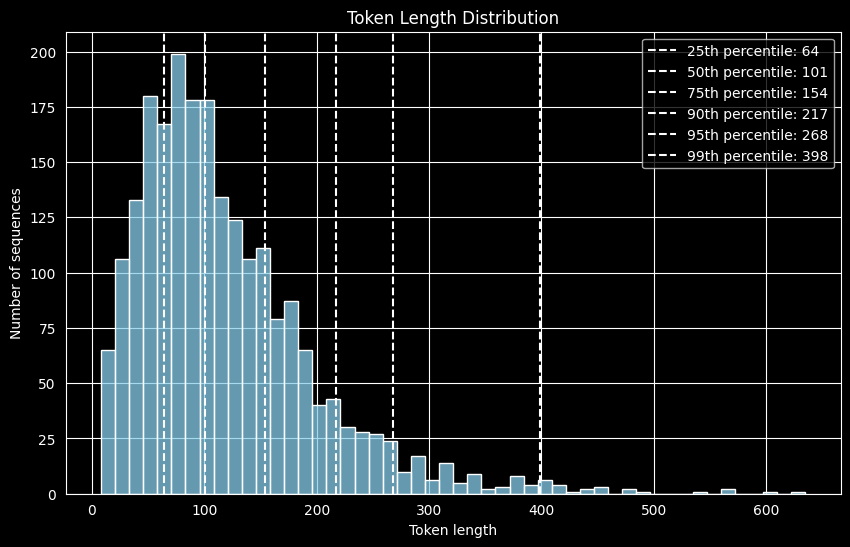

In [24]:
import pandas as pd
import numpy as np
from tqdm import tqdm

df = pd.read_csv('baseline_data/dev.csv', sep=',')

token_lengths = []
for entry in tqdm(df['entries'], desc="Tokenizing entries"):
    if not isinstance(entry, str):
        entry = str(entry)
    token_lengths.append(len(tokenizer(entry).input_ids))

token_lengths = np.array(token_lengths)

avg_length = np.mean(token_lengths)
median_length = np.median(token_lengths)
percentiles = np.percentile(token_lengths, [25, 50, 75, 90, 95, 99])

print(f"Average token length: {avg_length:.2f}")
print(f"Median token length: {median_length}")
print("Percentiles (25th, 50th, 75th, 90th, 95th, 99th):", percentiles)

plt.figure(figsize=(10, 6))
sns.histplot(token_lengths, bins=50, kde=False, color="skyblue")
plt.title("Token Length Distribution")
plt.xlabel("Token length")
plt.ylabel("Number of sequences")

for p, val in zip([25, 50, 75, 90, 95, 99], percentiles):
    plt.axvline(val, linestyle='--', label=f'{p}th percentile: {int(val)}')

plt.legend()
plt.show()